# 05 - Hyperparameter Tuning / Hiperparametrizacion (ITG Stamina)

**ES:** Este notebook implementa una fase completa de hiperparametrizacion para mejorar los modelos de prediccion de dificultad en charts de stamina ITG.

**EN:** This notebook implements a complete hyperparameter tuning phase to improve difficulty prediction models for ITG stamina charts.

## Objetivo / Objective
- Explicar que es la hiperparametrizacion y por que aporta valor en este problema.
- Ejecutar una metodologia robusta con **Nested Cross-Validation** + **GridSearchCV**.
- Comparar baseline vs tuned en MAE, R2 y tolerancias de error (plus-minus 0.25, 0.50, 1.00).
- Interpretar resultados con enfoque estadistico y de dominio ITG stamina.
- Exportar el mejor modelo tuned y un CSV final de predicciones.

## Roadmap / Plan de trabajo

1. Setup reproducible y carga de datos.
2. Marco teorico: que es hiperparametrizacion y por que usar Nested CV.
3. Definicion de pipelines y grids por modelo.
4. Ejecucion de baseline y tuned con nested evaluation.
5. Comparacion de resultados, visualizacion e interpretacion.
6. Seleccion final, reentrenamiento full-data y export de artefactos.

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Any

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 120)

print('Imports loaded successfully.')

Imports loaded successfully.


## 1) Reproducible setup and data loading / Setup reproducible y carga de datos

**ES:** Reutilizamos exactamente el mismo conjunto de features de produccion definido en el notebook 04 para garantizar comparabilidad justa entre baseline y tuned.

**EN:** We reuse the exact same production-aligned feature set from notebook 04 to guarantee a fair baseline-vs-tuned comparison.

In [2]:
RANDOM_STATE: int = 42
N_JOBS: int = -1

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != 'notebooks':
    NOTEBOOK_DIR = Path('../ml-core/notebooks').resolve()

CORE_DIR = NOTEBOOK_DIR.parent
PROCESSED_DIR = CORE_DIR / 'data' / 'processed'
MODELS_DIR = CORE_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

dataset_path = PROCESSED_DIR / 'stamina_dataset.csv'
df = pd.read_csv(dataset_path)

drop_columns = [col for col in ['average_nps', 'ebpm'] if col in df.columns]
df_model = df.drop(columns=drop_columns)

if 'display_BPM' in df_model.columns:
    bpm_column = 'display_BPM'
elif 'display_bpm' in df_model.columns:
    bpm_column = 'display_bpm'
else:
    raise KeyError("Neither 'display_BPM' nor 'display_bpm' exists in the dataset columns.")

feature_columns = [
    'total_stream_length',
    'max_stream_length',
    'break_count',
    'stream_break_ratio',
    bpm_column,
]

X = df_model[feature_columns].copy().fillna(0)
X = X.rename(columns={bpm_column: 'display_BPM'})
y = df_model['difficulty'].copy()

print(f'Dataset: {dataset_path}')
print(f'Shape X: {X.shape} | Shape y: {y.shape}')
print(f'Features used: {list(X.columns)}')

Dataset: c:\Users\maru\Documents\Uni\Tesina\ITGStamina-rater-ml\ml-core\data\processed\stamina_dataset.csv
Shape X: (2852, 5) | Shape y: (2852,)
Features used: ['total_stream_length', 'max_stream_length', 'break_count', 'stream_break_ratio', 'display_BPM']


## 2) Conceptual frame / Marco conceptual

### Que es hiperparametrizacion? / What is hyperparameter tuning?
**ES:** Los hiperparametros son configuraciones del modelo definidas antes del entrenamiento (por ejemplo, `max_depth`, `C`, `learning_rate`). No se aprenden directamente de los datos; se seleccionan por busqueda y validacion.

**EN:** Hyperparameters are model settings defined before training (e.g., `max_depth`, `C`, `learning_rate`). They are not directly learned from data; they are selected through search and validation.

### Por que Nested CV? / Why Nested CV?
**ES:** Si tuneamos y evaluamos en el mismo esquema, podemos sobreestimar rendimiento. Nested CV separa claramente la seleccion de hiperparametros (inner CV) de la estimacion de generalizacion (outer CV).

**EN:** If we tune and evaluate in the same loop, we risk optimistic bias. Nested CV cleanly separates hyperparameter selection (inner CV) from generalization estimation (outer CV).

Flujo:
1. Outer fold define train/test temporal de evaluacion.
2. En el train outer se ejecuta GridSearchCV con inner folds.
3. El mejor modelo inner se evalua en test outer.
4. Repetir en todos los outer folds y promediar resultados.

In [3]:
def tolerance_accuracy_summary(
    y_true: pd.Series | np.ndarray,
    y_pred: np.ndarray,
    tolerances: tuple[float, ...] = (0.25, 0.50, 1.00),
) -> dict[str, float]:
    """
    EN: Compute cumulative accuracies at multiple absolute-error tolerances.
    ES: Calcula accuracies acumuladas para multiples tolerancias de error absoluto.
    """
    y_true_array = np.asarray(y_true)
    y_pred_array = np.asarray(y_pred)
    abs_error = np.abs(y_true_array - y_pred_array)

    return {
        f'Acc +/-{tol:.2f} (%)': float(np.mean(abs_error <= tol) * 100.0)
        for tol in tolerances
    }


def absolute_error_bands(y_true: pd.Series | np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    """
    EN: Break down percentage of samples across absolute-error bands.
    ES: Desglosa el porcentaje de muestras por bandas de error absoluto.
    """
    y_true_array = np.asarray(y_true)
    y_pred_array = np.asarray(y_pred)
    abs_error = np.abs(y_true_array - y_pred_array)

    return {
        'Err <=0.25 (%)': float(np.mean(abs_error <= 0.25) * 100.0),
        'Err (0.25,0.50] (%)': float(np.mean((abs_error > 0.25) & (abs_error <= 0.50)) * 100.0),
        'Err (0.50,1.00] (%)': float(np.mean((abs_error > 0.50) & (abs_error <= 1.00)) * 100.0),
        'Err >1.00 (%)': float(np.mean(abs_error > 1.00) * 100.0),
    }


def regression_metrics_bundle(y_true: pd.Series | np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    """
    EN: Aggregate regression and tolerance metrics into one dictionary.
    ES: Agrupa metricas de regresion y de tolerancia en un unico diccionario.
    """
    summary: dict[str, float] = {
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'R2': float(r2_score(y_true, y_pred)),
    }
    summary.update(tolerance_accuracy_summary(y_true, y_pred))
    summary.update(absolute_error_bands(y_true, y_pred))
    return summary


def summarize_fold_results(fold_df: pd.DataFrame, label: str) -> pd.DataFrame:
    """
    EN: Summarize fold-level metrics with mean and std by model.
    ES: Resume metricas por fold con media y desvio estandar por modelo.
    """
    summary = (
        fold_df.groupby('Model', as_index=False)
        .agg(
            Mean_MAE=('MAE', 'mean'),
            Std_MAE=('MAE', 'std'),
            Mean_R2=('R2', 'mean'),
            Std_R2=('R2', 'std'),
            Mean_Acc025=('Acc +/-0.25 (%)', 'mean'),
            Mean_Acc050=('Acc +/-0.50 (%)', 'mean'),
            Mean_Acc100=('Acc +/-1.00 (%)', 'mean'),
            Mean_Err_gt1=('Err >1.00 (%)', 'mean'),
        )
        .sort_values('Mean_MAE', ascending=True)
        .reset_index(drop=True)
    )
    summary['Setting'] = label
    return summary


print('Metric helper functions ready.')

Metric helper functions ready.


## 3) Model definitions and search spaces / Definicion de modelos y espacios de busqueda

**ES:** Definimos los mismos tres modelos del notebook 04 para mantener continuidad metodologica. Sobre cada uno aplicamos un grid orientado a sesgo-varianza y robustez en este dataset.

**EN:** We keep the same three models from notebook 04 for methodological continuity. For each model, we apply a grid targeting bias-variance tradeoffs and robustness on this dataset.

In [4]:
model_pipelines: dict[str, Pipeline] = {
    'SVR (Banatt Baseline)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVR(C=1.0, epsilon=0.1)),
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)),
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('model', HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
    ]),
}

param_grids: dict[str, dict[str, list[Any]]] = {
    'SVR (Banatt Baseline)': {
        'model__kernel': ['linear', 'rbf'],
        'model__C': [0.5, 1.0, 2.0, 5.0, 10.0],
        'model__epsilon': [0.01, 0.05, 0.10, 0.20],
        'model__gamma': ['scale', 'auto'],
    },
    'Random Forest': {
        'model__n_estimators': [150, 300, 500],
        'model__max_depth': [None, 8, 14, 20],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': [1.0, 'sqrt'],
    },
    'Gradient Boosting': {
        'model__learning_rate': [0.03, 0.05, 0.10],
        'model__max_depth': [None, 5, 9],
        'model__max_iter': [200, 400],
        'model__min_samples_leaf': [10, 20, 40],
        'model__l2_regularization': [0.0, 0.1, 1.0],
    },
}

for model_name, grid in param_grids.items():
    combinations = int(np.prod([len(v) for v in grid.values()]))
    print(f'{model_name:<24} -> {combinations} combinations')

print('Model pipelines and parameter grids initialized.')

SVR (Banatt Baseline)    -> 80 combinations
Random Forest            -> 216 combinations
Gradient Boosting        -> 162 combinations
Model pipelines and parameter grids initialized.


## 4) Nested CV implementation / Implementacion de Nested CV

**ES:** En cada outer fold calculamos dos lineas:
- Baseline: sin tuning, parametros por defecto del notebook 04.
- Tuned: GridSearchCV en inner folds y evaluacion en el test outer.

**EN:** For each outer fold we compute two lines:
- Baseline: no tuning, notebook-04 style defaults.
- Tuned: GridSearchCV in inner folds and evaluation on the outer test fold.

In [5]:
outer_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE + 1)

baseline_rows: list[dict[str, Any]] = []
tuned_rows: list[dict[str, Any]] = []
inner_top_rows: list[dict[str, Any]] = []

for model_name, base_pipeline in model_pipelines.items():
    print(f'\n=== Running nested evaluation for: {model_name} ===')
    model_grid = param_grids[model_name]

    for fold_id, (train_idx, test_idx) in enumerate(outer_cv.split(X), start=1):
        X_outer_train = X.iloc[train_idx]
        y_outer_train = y.iloc[train_idx]
        X_outer_test = X.iloc[test_idx]
        y_outer_test = y.iloc[test_idx]

        baseline_estimator = clone(base_pipeline)
        baseline_estimator.fit(X_outer_train, y_outer_train)
        baseline_pred = baseline_estimator.predict(X_outer_test)
        baseline_metrics = regression_metrics_bundle(y_outer_test, baseline_pred)
        baseline_metrics.update({
            'Model': model_name,
            'Outer Fold': fold_id,
        })
        baseline_rows.append(baseline_metrics)

        grid_search = GridSearchCV(
            estimator=clone(base_pipeline),
            param_grid=model_grid,
            scoring='neg_mean_absolute_error',
            cv=inner_cv,
            n_jobs=N_JOBS,
            refit=True,
            verbose=0,
            return_train_score=False,
        )
        grid_search.fit(X_outer_train, y_outer_train)

        tuned_pred = grid_search.best_estimator_.predict(X_outer_test)
        tuned_metrics = regression_metrics_bundle(y_outer_test, tuned_pred)
        tuned_metrics.update({
            'Model': model_name,
            'Outer Fold': fold_id,
            'Inner Best MAE': float(-grid_search.best_score_),
            'Best Params': grid_search.best_params_,
        })
        tuned_rows.append(tuned_metrics)

        fold_cv = pd.DataFrame(grid_search.cv_results_).sort_values('rank_test_score').head(3)
        for _, cv_row in fold_cv.iterrows():
            inner_top_rows.append({
                'Model': model_name,
                'Outer Fold': fold_id,
                'Inner Rank': int(cv_row['rank_test_score']),
                'Inner MAE': float(-cv_row['mean_test_score']),
                'Params': cv_row['params'],
            })

        print(
            f'Fold {fold_id}: baseline MAE={baseline_metrics["MAE"]:.4f} | '
            f'tuned MAE={tuned_metrics["MAE"]:.4f} | '
            f'inner best MAE={tuned_metrics["Inner Best MAE"]:.4f}'
        )

baseline_fold_df = pd.DataFrame(baseline_rows)
tuned_fold_df = pd.DataFrame(tuned_rows)
inner_top_df = pd.DataFrame(inner_top_rows)

print('\nNested evaluation completed.')
print(f'Baseline rows: {len(baseline_fold_df)} | Tuned rows: {len(tuned_fold_df)}')


=== Running nested evaluation for: SVR (Banatt Baseline) ===
Fold 1: baseline MAE=0.5412 | tuned MAE=0.3692 | inner best MAE=0.4120
Fold 2: baseline MAE=0.5080 | tuned MAE=0.3600 | inner best MAE=0.4152
Fold 3: baseline MAE=0.4913 | tuned MAE=0.3832 | inner best MAE=0.4015
Fold 4: baseline MAE=0.5557 | tuned MAE=0.4188 | inner best MAE=0.4130
Fold 5: baseline MAE=0.5679 | tuned MAE=0.4302 | inner best MAE=0.3872

=== Running nested evaluation for: Random Forest ===
Fold 1: baseline MAE=0.3337 | tuned MAE=0.3292 | inner best MAE=0.3620
Fold 2: baseline MAE=0.3350 | tuned MAE=0.3370 | inner best MAE=0.3521
Fold 3: baseline MAE=0.3420 | tuned MAE=0.3458 | inner best MAE=0.3524
Fold 4: baseline MAE=0.3456 | tuned MAE=0.3461 | inner best MAE=0.3635
Fold 5: baseline MAE=0.3605 | tuned MAE=0.3531 | inner best MAE=0.3581

=== Running nested evaluation for: Gradient Boosting ===
Fold 1: baseline MAE=0.3348 | tuned MAE=0.3253 | inner best MAE=0.3510
Fold 2: baseline MAE=0.3471 | tuned MAE=0.333

## 5) Results and comparison / Resultados y comparacion

**ES:** Esta seccion responde dos preguntas: (1) mejora real en error promedio? (2) mejora estable entre folds?

**EN:** This section answers two questions: (1) is average error truly improved? (2) is the improvement stable across folds?

In [6]:
baseline_summary = summarize_fold_results(baseline_fold_df, label='Baseline')
tuned_summary = summarize_fold_results(tuned_fold_df, label='Tuned')

comparison_df = (
    baseline_summary.merge(
        tuned_summary,
        on='Model',
        suffixes=('_baseline', '_tuned'),
    )
    .assign(
        Delta_MAE=lambda d: d['Mean_MAE_baseline'] - d['Mean_MAE_tuned'],
        Delta_R2=lambda d: d['Mean_R2_tuned'] - d['Mean_R2_baseline'],
        Delta_Acc100=lambda d: d['Mean_Acc100_tuned'] - d['Mean_Acc100_baseline'],
        Delta_Err_gt1=lambda d: d['Mean_Err_gt1_baseline'] - d['Mean_Err_gt1_tuned'],
    )
    .sort_values('Delta_MAE', ascending=False)
    .reset_index(drop=True)
)

print('Baseline summary (outer folds):')
display(baseline_summary)

print('Tuned summary (outer folds):')
display(tuned_summary)

print('Delta table (positive Delta_MAE means tuned is better):')
display(comparison_df)

print('Top inner configurations sampled during nested search:')
display(inner_top_df.head(15))

Baseline summary (outer folds):


,Model,Mean_MAE,Std_MAE,Mean_R2,Std_R2,Mean_Acc025,Mean_Acc050,Mean_Acc100,Mean_Err_gt1,Setting
0,Random Forest,0.343372,0.010790,0.993267,0.001169,52.734876,75.525916,95.827019,4.172981,Baseline
1,Gradient Boosting,0.351785,0.014207,0.993400,0.000954,47.721510,76.857591,96.142563,3.857437,Baseline
2,SVR (Banatt Baseline),0.532823,0.032268,0.976457,0.008397,37.729069,66.375211,90.848680,9.151320,Baseline


Tuned summary (outer folds):


,Model,Mean_MAE,Std_MAE,Mean_R2,Std_R2,Mean_Acc025,Mean_Acc050,Mean_Acc100,Mean_Err_gt1,Setting
0,Gradient Boosting,0.338000,0.009756,0.994047,0.000983,49.473991,78.611362,96.738686,3.261314,Tuned
1,Random Forest,0.342249,0.009266,0.993298,0.001124,52.524227,74.859803,95.897133,4.102867,Tuned
2,SVR (Banatt Baseline),0.392280,0.030800,0.987800,0.007357,43.548530,75.876241,95.651765,4.348235,Tuned


Delta table (positive Delta_MAE means tuned is better):


,Model,Mean_MAE_baseline,Std_MAE_baseline,Mean_R2_baseline,Std_R2_baseline,Mean_Acc025_baseline,Mean_Acc050_baseline,Mean_Acc100_baseline,Mean_Err_gt1_baseline,Setting_baseline,...,Std_R2_tuned,Mean_Acc025_tuned,Mean_Acc050_tuned,Mean_Acc100_tuned,Mean_Err_gt1_tuned,Setting_tuned,Delta_MAE,Delta_R2,Delta_Acc100,Delta_Err_gt1
0,SVR (Banatt Baseline),0.532823,0.032268,0.976457,0.008397,37.729069,66.375211,90.848680,9.151320,Baseline,...,0.007357,43.548530,75.876241,95.651765,4.348235,Tuned,0.140542,0.011344,4.803085,4.803085
1,Gradient Boosting,0.351785,0.014207,0.993400,0.000954,47.721510,76.857591,96.142563,3.857437,Baseline,...,0.000983,49.473991,78.611362,96.738686,3.261314,Tuned,0.013785,0.000647,0.596123,0.596123
2,Random Forest,0.343372,0.010790,0.993267,0.001169,52.734876,75.525916,95.827019,4.172981,Baseline,...,0.001124,52.524227,74.859803,95.897133,4.102867,Tuned,0.001123,0.000030,0.070114,0.070114


Top inner configurations sampled during nested search:


,Model,Outer Fold,Inner Rank,Inner MAE,Params
0,SVR (Banatt Baseline),1,1,0.412006,"{'model__C': 10.0, 'model__epsilon': 0.05, 'model__gamma': 'scale', 'model__kernel': 'rbf'}"
1,SVR (Banatt Baseline),1,1,0.412006,"{'model__C': 10.0, 'model__epsilon': 0.05, 'model__gamma': 'auto', 'model__kernel': 'rbf'}"
2,SVR (Banatt Baseline),1,3,0.412418,"{'model__C': 10.0, 'model__epsilon': 0.01, 'model__gamma': 'auto', 'model__kernel': 'rbf'}"
3,SVR (Banatt Baseline),2,1,0.415193,"{'model__C': 10.0, 'model__epsilon': 0.01, 'model__gamma': 'auto', 'model__kernel': 'rbf'}"
4,SVR (Banatt Baseline),2,1,0.415193,"{'model__C': 10.0, 'model__epsilon': 0.01, 'model__gamma': 'scale', 'model__kernel': 'rbf'}"
5,SVR (Banatt Baseline),2,3,0.415666,"{'model__C': 10.0, 'model__epsilon': 0.05, 'model__gamma': 'scale', 'model__kernel': 'rbf'}"
6,SVR (Banatt Baseline),3,1,0.401544,"{'model__C': 10.0, 'model__epsilon': 0.01, 'model__gamma': 'auto', 'model__kernel': 'rbf'}"
7,SVR (Banatt Baseline),3,1,0.401544,"{'model__C': 10.0, 'model__epsilon': 0.01, 'model__gamma': 'scale', 'model__kernel': 'rbf'}"
8,SVR (Banatt Baseline),3,3,0.402121,"{'model__C': 10.0, 'model__epsilon': 0.1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}"
9,SVR (Banatt Baseline),4,1,0.413038,"{'model__C': 10.0, 'model__epsilon': 0.01, 'model__gamma': 'auto', 'model__kernel': 'rbf'}"


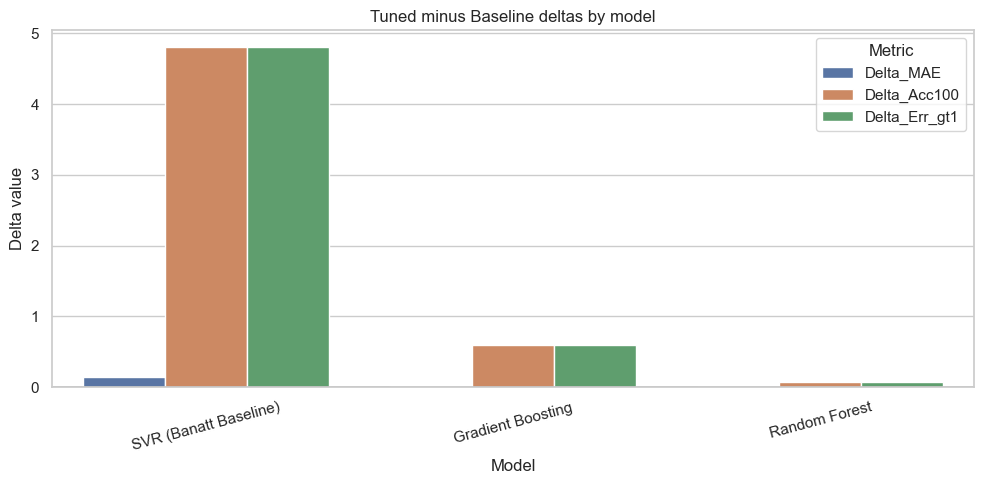

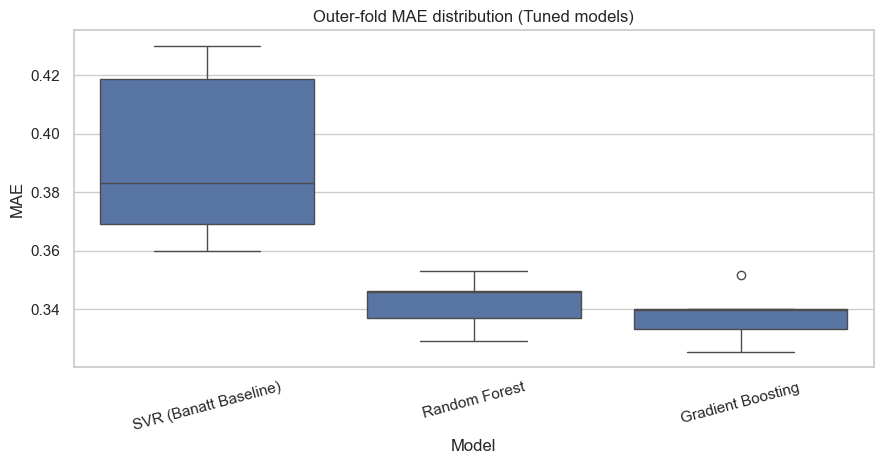

In [7]:
plot_df = comparison_df[['Model', 'Delta_MAE', 'Delta_Acc100', 'Delta_Err_gt1']].melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Delta',
)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x='Model', y='Delta', hue='Metric')
plt.axhline(0.0, color='black', linewidth=1.0)
plt.title('Tuned minus Baseline deltas by model')
plt.ylabel('Delta value')
plt.xlabel('Model')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

mae_spread_df = tuned_fold_df[['Model', 'MAE']].copy()
plt.figure(figsize=(9, 4.8))
sns.boxplot(data=mae_spread_df, x='Model', y='MAE')
plt.title('Outer-fold MAE distribution (Tuned models)')
plt.xlabel('Model')
plt.ylabel('MAE')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 6) Final model selection, retraining, and export / Seleccion final, reentrenamiento y export

**Criterio principal / Main criterion:** menor Mean_MAE en tuned summary.

**Criterio secundario / Secondary criterion:** menor Std_MAE y mejor Mean_Acc100 para estabilidad y utilidad practica.

In [8]:
winner_row = tuned_summary.sort_values(
    by=['Mean_MAE', 'Std_MAE', 'Mean_Acc100'],
    ascending=[True, True, False],
).iloc[0]
winning_model_name = str(winner_row['Model'])

print(f'Winning tuned model: {winning_model_name}')

final_search = GridSearchCV(
    estimator=clone(model_pipelines[winning_model_name]),
    param_grid=param_grids[winning_model_name],
    scoring='neg_mean_absolute_error',
    cv=inner_cv,
    n_jobs=N_JOBS,
    refit=True,
    verbose=0,
)
final_search.fit(X, y)
final_model_full = final_search.best_estimator_

print(f'Final best MAE (inner CV on full data): {-final_search.best_score_:.4f}')
print('Final best params:')
print(final_search.best_params_)

model_output_path = MODELS_DIR / 'stamina_model_v2.pkl'
joblib.dump(final_model_full, model_output_path)

chart_col_candidates = [
    'source_file', 'chart_id', 'title', 'chart', 'chart_name', 'simfile_path', 'file_path', 'hash'
]
chart_col = next((col for col in chart_col_candidates if col in df.columns), None)
if chart_col is None:
    chart_series = pd.Series(df.index.astype(str), index=df.index)
else:
    chart_series = df[chart_col].astype(str)

breakdown_series = df['breakdown'].astype(str) if 'breakdown' in df.columns else pd.Series(['N/A'] * len(df), index=df.index)
bpm_series = X['display_BPM']
true_difficulty = df['difficulty'].astype(int)
pred_values = final_model_full.predict(X)
pred_difficulty = [f'{value:.2f}' for value in pred_values]

predictions_df = pd.DataFrame({
    'chart_to_classify': chart_series,
    'breakdown': breakdown_series,
    'BPM': bpm_series,
    'difficulty': true_difficulty,
    'predicted_difficulty': pred_difficulty,
})

predictions_output_path = PROCESSED_DIR / 'stamina_predictions_full_v2.csv'
predictions_df.to_csv(predictions_output_path, index=False)

print(f'Model exported: {model_output_path.resolve()}')
print(f'Predictions exported: {predictions_output_path.resolve()}')
print(f'Chart identifier used: {chart_col if chart_col is not None else "index"}')
print(f'Rows exported: {len(predictions_df)}')

Winning tuned model: Gradient Boosting
Final best MAE (inner CV on full data): 0.3405
Final best params:
{'model__l2_regularization': 1.0, 'model__learning_rate': 0.03, 'model__max_depth': None, 'model__max_iter': 400, 'model__min_samples_leaf': 10}
Model exported: C:\Users\maru\Documents\Uni\Tesina\ITGStamina-rater-ml\ml-core\models\stamina_model_v2.pkl
Predictions exported: C:\Users\maru\Documents\Uni\Tesina\ITGStamina-rater-ml\ml-core\data\processed\stamina_predictions_full_v2.csv
Chart identifier used: source_file
Rows exported: 2852


In [9]:
winner_comparison = comparison_df.loc[comparison_df['Model'] == winning_model_name].iloc[0]

print('=== Interpretation block / Bloque de interpretacion ===')
print(f'Model selected: {winning_model_name}')
print(f'MAE improvement (baseline - tuned): {winner_comparison["Delta_MAE"]:.4f}')
print(f'R2 improvement (tuned - baseline): {winner_comparison["Delta_R2"]:.4f}')
print(f'Acc +/-1.00 improvement (pp): {winner_comparison["Delta_Acc100"]:.2f}')
print(f'Reduction in error >1.00 (pp): {winner_comparison["Delta_Err_gt1"]:.2f}')

stability_flag = 'stable' if float(winner_row['Std_MAE']) < 0.35 else 'variable'
print(f'Outer-fold behavior appears: {stability_flag}')

print('\nES: Si Delta_MAE > 0 y Delta_Err_gt1 > 0, la hiperparametrizacion aporta mejora practica real.')
print('EN: If Delta_MAE > 0 and Delta_Err_gt1 > 0, tuning delivers practical improvement.')

=== Interpretation block / Bloque de interpretacion ===
Model selected: Gradient Boosting
MAE improvement (baseline - tuned): 0.0138
R2 improvement (tuned - baseline): 0.0006
Acc +/-1.00 improvement (pp): 0.60
Reduction in error >1.00 (pp): 0.60
Outer-fold behavior appears: stable

ES: Si Delta_MAE > 0 y Delta_Err_gt1 > 0, la hiperparametrizacion aporta mejora practica real.
EN: If Delta_MAE > 0 and Delta_Err_gt1 > 0, tuning delivers practical improvement.


## 7) Reading the results / Como interpretar los resultados

**ES:**
- Priorizar MAE promedio y su desvio para evaluar precision y estabilidad.
- Revisar Acc plus-minus 1.00 para utilidad de clasificacion por bloques cercanos.
- Usar Delta_Err_gt1 para cuantificar reduccion de errores grandes.
- Si hay mejoras pequenas con alta varianza, reportar la conclusion con cautela academica.

**EN:**
- Prioritize mean MAE and MAE std to assess both accuracy and stability.
- Check Acc plus-minus 1.00 for practical near-level classification utility.
- Use Delta_Err_gt1 to quantify reduction of large mistakes.
- If gains are small with high variance, report conclusions with academic caution.

## Expected deliverables / Entregables esperados
1. Tabla baseline vs tuned por modelo (media y std).
2. Visualizaciones de deltas e inestabilidad por fold.
3. Modelo final exportado: `stamina_model_v2.pkl`.
4. CSV de predicciones final: `stamina_predictions_full_v2.csv`.
5. Bloque de interpretacion listo para redaccion de tesis.